In [1]:
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from tqdm import tqdm
import sys
sys.path.append(r'\\192.168.10.106\imdea\DataDriven_UT_AlbertoVicente\10_code\UTvsXCT-preprocessing')
sys.path.append(r'/home/alberto.vicente/phd/DataDriven_UT_AlbertoVicente/10_code/UTvsXCT-preprocessing')

from preprocess_tools import aligner,onlypores,io,pore_filtering,reslicer

In [2]:
# Enhanced Professional Plot Theme Configuration
# Color palette: #4281a4 (primary blue), #4c3b4d (deep purple), #48a9a6 (teal), #e4dfda (light beige), #e980fc (magenta)

def apply_plot_theme():
    """Apply the enhanced professional plot theme to current figure"""
    fig = plt.gcf()
    ax = plt.gca()
    
    # Set figure size and colors
    fig.set_size_inches(10, 6)
    fig.patch.set_facecolor('#f8f6f4')  # Slightly warmer white background
    ax.set_facecolor('#fdfcfb')  # Very light warm background for plot area
    
    # Configure enhanced grid
    ax.grid(True, axis='y', alpha=0.4, color='#e4dfda', linewidth=0.8, linestyle='-')
    ax.grid(True, axis='x', alpha=0.2, color='#e4dfda', linewidth=0.5, linestyle=':')
    ax.set_axisbelow(True)
    
    # Enhanced text styling with better contrast
    ax.tick_params(colors='#4c3b4d', labelsize=11, width=1.2)  # Deep purple tick labels
    ax.xaxis.label.set_color('#4c3b4d')  # Deep purple for better readability
    ax.yaxis.label.set_color('#4c3b4d')  # Deep purple for better readability
    ax.xaxis.label.set_fontsize(13)
    ax.yaxis.label.set_fontsize(13)
    ax.xaxis.label.set_fontweight('medium')
    ax.yaxis.label.set_fontweight('medium')
    
    # Enhanced spine styling
    for spine in ax.spines.values():
        spine.set_color('#4c3b4d')
        spine.set_linewidth(1.3)
        spine.set_alpha(0.8)
    
    # Remove top and right spines for cleaner look
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    
    # Enhanced legend styling
    legend = ax.get_legend()
    if legend:
        legend.get_frame().set_facecolor('#fdfcfb')
        legend.get_frame().set_edgecolor('#4c3b4d')
        legend.get_frame().set_linewidth(1.2)
        legend.get_frame().set_alpha(0.95)
        for text in legend.get_texts():
            text.set_color('#4c3b4d')
            text.set_fontsize(11)
            text.set_fontweight('medium')
        # Add subtle shadow to legend
        legend.get_frame().set_boxstyle("round,pad=0.5")
    
    # Enhanced layout with better spacing
    plt.tight_layout(pad=2.5)
    
    # Subtle border around the entire plot
    fig.patch.set_linewidth(1)
    fig.patch.set_edgecolor('#e4dfda')

In [3]:
#load the onlypores to filter

file_path = Path(r"/home/alberto.vicente/phd/DataDriven_UT_AlbertoVicente/02_XCT_data/Fabricacion Nacho/05_Probetas_Nacho_2025/probetas/Na_01_1/volume_eq_aligned.tif")

volume = io.load_tif(file_path)

In [4]:
material = onlypores.material_mask(volume)

Computing material mask using sequential processing...
Filling internal voids...
Material mask generation complete.


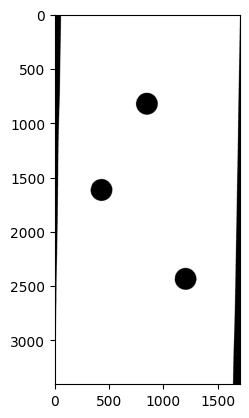

In [5]:
plt.imshow(material.max(axis=0),cmap='gray')

In [7]:
volume  = reslicer.rotate_90(volume,False)
volume = reslicer.reslice(volume,'Right')
material  = reslicer.rotate_90(material,False)
material = reslicer.reslice(material,'Right')

#get the frontwall and backwall of the xct volume
_,frontwall,backwall = aligner.crop_walls(volume, material)

volume = reslicer.reslice(volume,'Left')
volume  = reslicer.rotate_90(volume,True)
material = reslicer.reslice(material,'Left')
material  = reslicer.rotate_90(material,True)

print(frontwall, backwall)

8 193


# Thickness projection

In [31]:
thickness_map = np.count_nonzero(material,axis=0) * 0.025

In [47]:
figures_folder = Path(r'/home/alberto.vicente/phd/DataDriven_UT_AlbertoVicente/00_literature/05_Alberto_Vicente/01_FYA/First_Year/Figures')

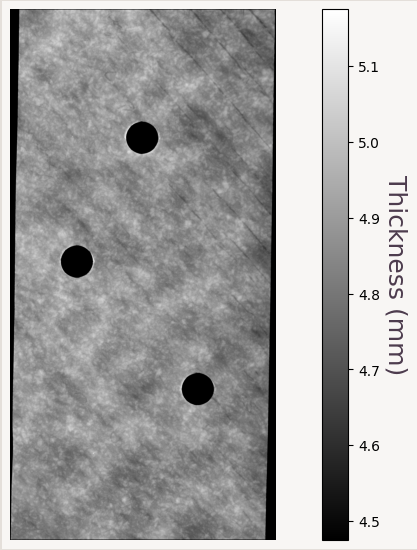

In [50]:
# Adjust vmin and vmax to control contrast
# Use percentiles to clip outliers and improve visualization
vmin = np.percentile(thickness_map, 5.7)
vmax = np.percentile(thickness_map, 100)

plt.imshow(thickness_map, cmap='gray', vmin=vmin, vmax=vmax)
cbar = plt.colorbar()
cbar.set_label('Thickness (mm)', rotation=270, labelpad=20, color='#4c3b4d', fontsize=18, fontweight='medium')
plt.axis('off')
apply_plot_theme()
plt.savefig(figures_folder / 'thickness_projection.pdf', bbox_inches='tight', dpi=300)